In [2]:
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np

from models import f_lin, f_quad, f_lin_2d, f_quad_2d
from sampler import HBM_log_likelihood, t_like_df1, t_like_df5, gauss_like

cmap = plt.cm.magma

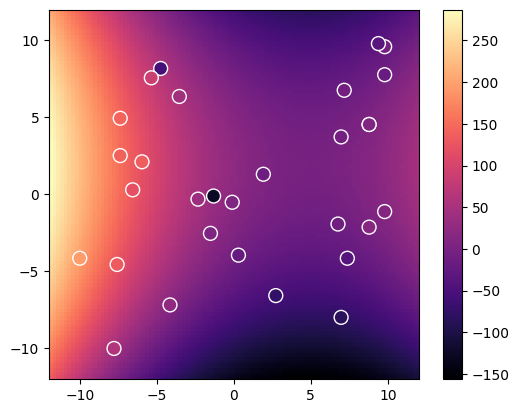

In [4]:
xx = np.linspace(-10, 10, 100)
yy = np.linspace(-10, 10, 100)
x = xx[np.random.randint(100, size=30)]
y = yy[np.random.randint(100, size=30)]
xx = np.linspace(-12, 12, 100)
yy = np.linspace(-12, 12, 100)

xxyy = np.concatenate(np.array(np.meshgrid(xx, yy)).T, axis=0)
xy = np.vstack([x, y]).T

true_a = 20
true_bx = -10
true_by = 3
true_cx = 1.0
true_cy = -0.8
trues = [true_a, true_bx, true_by, true_cx, true_cy]

sig_gauss = 10
sig_cauchy = 3
true_z = f_quad_2d(xy, trues) + np.random.standard_cauchy(len(x)) * sig_cauchy + np.random.randn(len(x)) * sig_gauss

sig0 = 10
sigs = np.random.rand(len(true_z)) * sig_gauss + sig0

nsamps = 10000
z_samples = jnp.array([zi + np.random.randn(nsamps) * s for zi, s in zip(true_z, sigs)])

true_model = f_quad_2d(xxyy, trues).reshape(100, 100)
im = plt.imshow(true_model.T, extent=(-12, 12, -12, 12), origin='lower', cmap=cmap)
vmin, vmax = im.get_clim()
plt.scatter(x, y, c=true_z, s=100, edgecolor='w', vmin=vmin, vmax=vmax, cmap=cmap)
plt.colorbar()

In [5]:
import emcee

initial = [20, -2, 3, -0.2, -0.1, 5]
pos = initial + 1e-4 * np.random.randn(32, len(initial))
nwalkers, ndim = pos.shape

ll = jax.jit(lambda p: HBM_log_likelihood(xy, p[:-1], p[-1:], z_samples, f_quad_2d, t_like_df1))
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, ll
)
sampler.run_mcmc(pos, 1000, progress=True);

100%|██████████████████████████████████████| 1000/1000 [00:06<00:00, 154.90it/s]


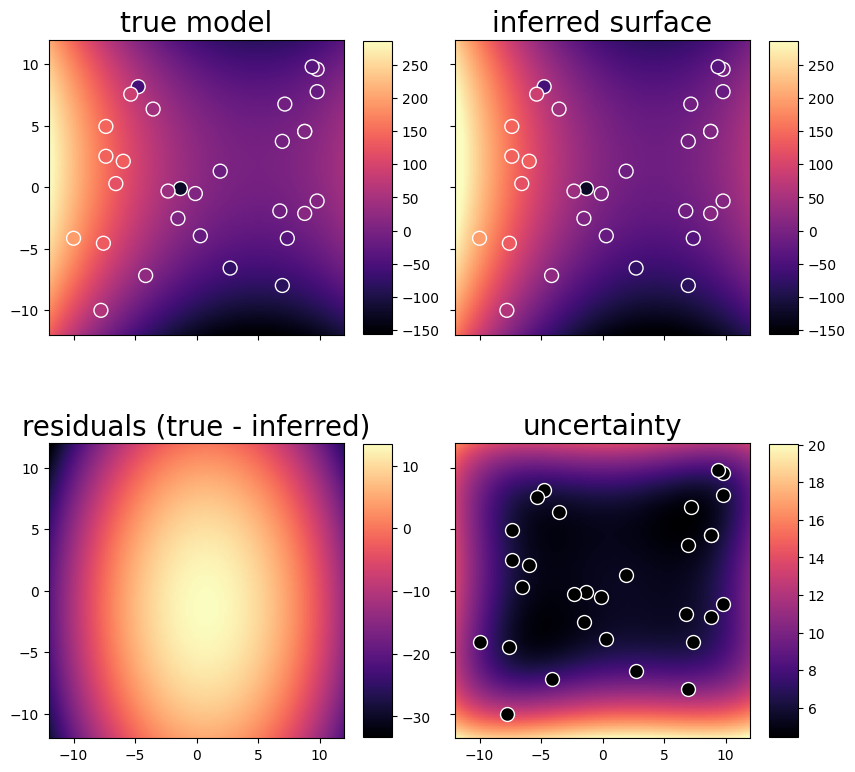

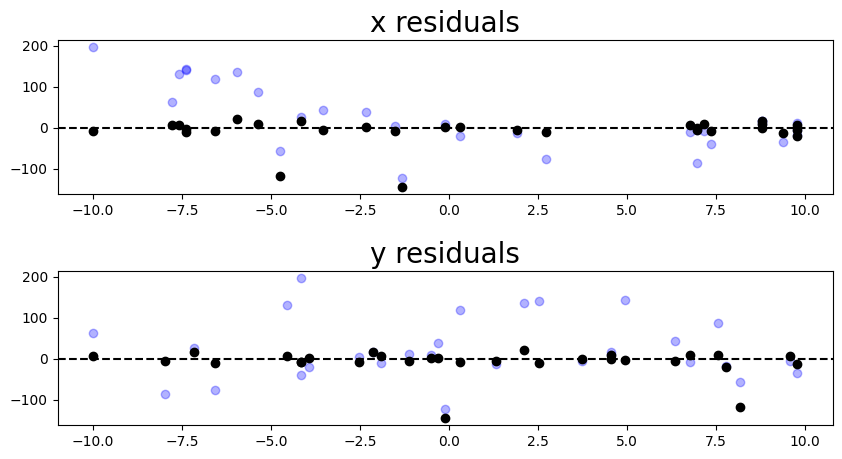

In [6]:
burnin=500
flat_samples = np.concatenate(sampler.get_chain()[burnin:, :, :], axis=0)
inds = np.random.randint(len(flat_samples), size=100)
models = np.array([f_quad_2d(xxyy, flat_samples[i][:-1]) for i in inds])
mean_model = np.mean(models, axis=0).reshape(100, 100)
std_surface = np.std(models, axis=0).reshape(100, 100)

fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharey=True, sharex=True, gridspec_kw={'hspace': 0.1, 'wspace': 0.1})
axs = axs.flatten()

extent = (-12, 12, -12, 12)

im = axs[0].imshow(true_model.T, extent=extent, origin='lower', cmap=cmap)
vmin, vmax = im.get_clim()
axs[0].scatter(x, y, c=true_z, s=100, edgecolor='w', vmin=vmin, vmax=vmax, cmap=cmap)
plt.colorbar(im, ax=axs[0], shrink=0.8, aspect=10)
axs[0].set_title('true model', fontsize=20)

im = axs[1].imshow(mean_model.reshape(100, 100).T, extent=extent, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
axs[1].scatter(x, y, c=true_z, s=100, edgecolor='w', vmin=vmin, vmax=vmax, cmap=cmap)
plt.colorbar(im, ax=axs[1], shrink=0.8, aspect=10)
axs[1].set_title('inferred surface', fontsize=20);

im = axs[2].imshow(true_model.T - mean_model.T, extent=extent, origin='lower', cmap=cmap)
plt.colorbar(im, ax=axs[2], shrink=0.8, aspect=10)
axs[2].set_title('residuals (true - inferred)', fontsize=20);

im = axs[3].imshow(std_surface.T, extent=extent, origin='lower', cmap=cmap)
axs[3].scatter(x, y, c='k', s=100, edgecolor='w')
plt.colorbar(im, ax=axs[3], shrink=0.8, aspect=10)
axs[3].set_title('uncertainty', fontsize=20);

fig, axs = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={'hspace': 0.5})

axs[0].plot(x, true_z, 'bo', alpha=0.3)
axs[0].plot(x, true_z - f_quad_2d(xy, np.mean(flat_samples, axis=0)[:-1]), 'ko')
axs[0].set_title('x residuals', fontsize=20)
axs[0].axhline(0, linestyle='--', color='k')

axs[1].plot(y, true_z, 'bo', alpha=0.3)
axs[1].plot(y, true_z - f_quad_2d(xy, np.mean(flat_samples, axis=0)[:-1]), 'ko')
axs[1].set_title('y residuals', fontsize=20)
axs[1].axhline(0, linestyle='--', color='k')